In [1]:
import pandas as pd

df = pd.read_csv("ga4_obfuscated_sample_ecommerce_Jan2021 - ga4_event_2021.csv")

In [2]:
df.head()

,event_date,event_timestamp,event_name,event_params.key,event_params.value.string_value,event_params.value.int_value,event_params.value.float_value,event_params.value.double_value,event_previous_timestamp,event_value_in_usd,...,items.coupon,items.affiliation,items.location_id,items.item_list_id,items.item_list_name,items.item_list_index,items.promotion_id,items.promotion_name,items.creative_name,items.creative_slot
0,20210121.0,1.611210e+15,page_view,engagement_time_msec,NaN,13.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,debug_mode,NaN,1.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,ga_session_number,NaN,1.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,page_referrer,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,page_location,https://www.googlemerchandisestore.com/,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 94 columns):
 #   Column                                      Non-Null Count  Dtype  
---  ------                                      --------------  -----  
 0   event_date                                  55 non-null     float64
 1   event_timestamp                             55 non-null     float64
 2   event_name                                  55 non-null     object 
 3   event_params.key                            497 non-null    object 
 4   event_params.value.string_value             200 non-null    object 
 5   event_params.value.int_value                257 non-null    float64
 6   event_params.value.float_value              0 non-null      float64
 7   event_params.value.double_value             0 non-null      float64
 8   event_previous_timestamp                    0 non-null      float64
 9   event_value_in_usd                          0 non-null      float64
 10  event_bundle_s

In [4]:
# Remove columns with more than 70% missing values
threshold = len(df) * 0.7

df = df.dropna(thresh=threshold, axis=1)

# Check remaining columns
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 1 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   event_params.key  497 non-null    object
dtypes: object(1)
memory usage: 4.0+ KB


In [6]:
df = pd.read_csv("ga4_obfuscated_sample_ecommerce_Jan2021 - ga4_event_2021.csv")

df = df[df['event_name'].notnull()]

print(df.shape)

df.head()

(55, 94)


,event_date,event_timestamp,event_name,event_params.key,event_params.value.string_value,event_params.value.int_value,event_params.value.float_value,event_params.value.double_value,event_previous_timestamp,event_value_in_usd,...,items.coupon,items.affiliation,items.location_id,items.item_list_id,items.item_list_name,items.item_list_index,items.promotion_id,items.promotion_name,items.creative_name,items.creative_slot
0,20210121.0,1.611210e+15,page_view,engagement_time_msec,NaN,13.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,20210121.0,1.611210e+15,page_view,page_referrer,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
24,20210129.0,1.611960e+15,view_promotion,ga_session_number,NaN,1.0,NaN,NaN,NaN,NaN,...,(not set),(not set),(not set),(not set),(not set),Slide 1,(not set),Reach New Heights,Front Page Carousel,(not set)
32,20210103.0,1.609700e+15,session_start,page_location,https://shop.googlemerchandisestore.com/Google...,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
37,20210113.0,1.610550e+15,first_visit,page_location,https://shop.googlemerchandisestore.com/Google...,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [7]:
df['event_name'].value_counts()

event_name
page_view           13
scroll              11
session_start        8
view_promotion       7
user_engagement      7
first_visit          5
view_item            3
select_promotion     1
Name: count, dtype: int64

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

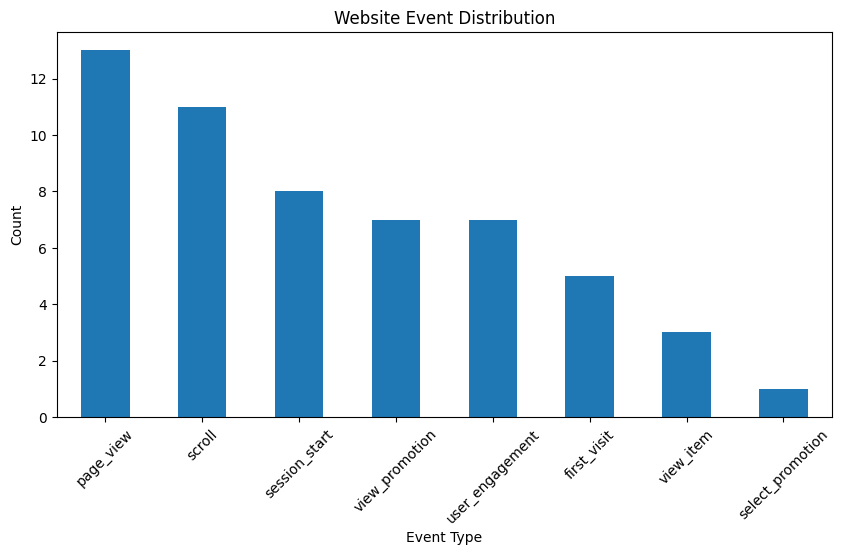

In [10]:
plt.figure(figsize=(10,5))

df['event_name'].value_counts().plot(kind='bar')

plt.title("Website Event Distribution")
plt.xlabel("Event Type")
plt.ylabel("Count")

plt.xticks(rotation=45)

plt.show()

In [11]:
df['traffic_source.source'].value_counts()

traffic_source.source
google                             20
<Other>                            14
(direct)                           13
shop.googlemerchandisestore.com     7
(data deleted)                      1
Name: count, dtype: int64

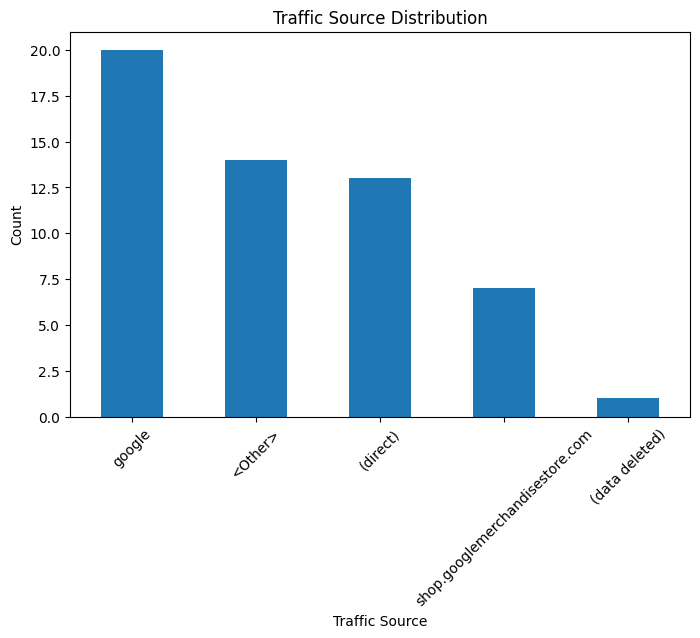

In [12]:
plt.figure(figsize=(8,5))

df['traffic_source.source'].value_counts().plot(kind='bar')

plt.title("Traffic Source Distribution")
plt.xlabel("Traffic Source")
plt.ylabel("Count")

plt.xticks(rotation=45)

plt.show()

In [13]:
df['device.category'].value_counts()

device.category
desktop    37
mobile     18
Name: count, dtype: int64

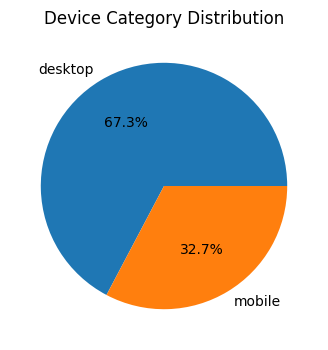

In [14]:
plt.figure(figsize=(6,4))

df['device.category'].value_counts().plot(kind='pie', autopct='%1.1f%%')

plt.title("Device Category Distribution")

plt.ylabel("")

plt.show()

In [15]:
df['device.web_info.browser'].value_counts()

device.web_info.browser
Chrome     43
Safari      9
Edge        2
<Other>     1
Name: count, dtype: int64

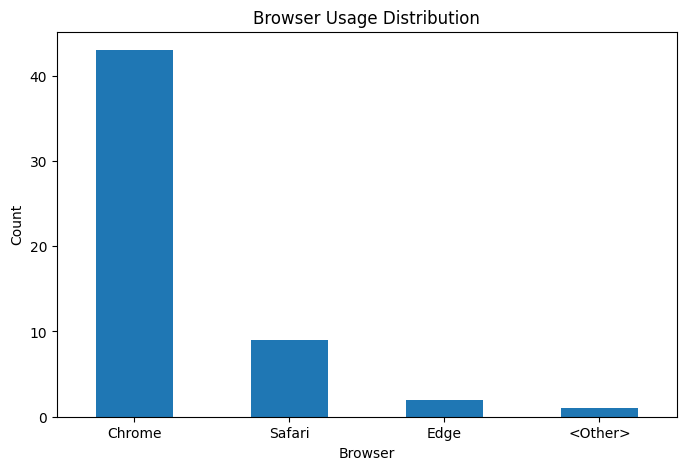

In [16]:
plt.figure(figsize=(8,5))

df['device.web_info.browser'].value_counts().plot(kind='bar')

plt.title("Browser Usage Distribution")
plt.xlabel("Browser")
plt.ylabel("Count")

plt.xticks(rotation=0)

plt.show()

In [17]:
engagement_count = (df['event_name'] == 'user_engagement').sum()

print("Total User Engagement Events:", engagement_count)

Total User Engagement Events: 7


In [18]:
event_counts = df['event_name'].value_counts()

print(event_counts)

event_name
page_view           13
scroll              11
session_start        8
view_promotion       7
user_engagement      7
first_visit          5
view_item            3
select_promotion     1
Name: count, dtype: int64


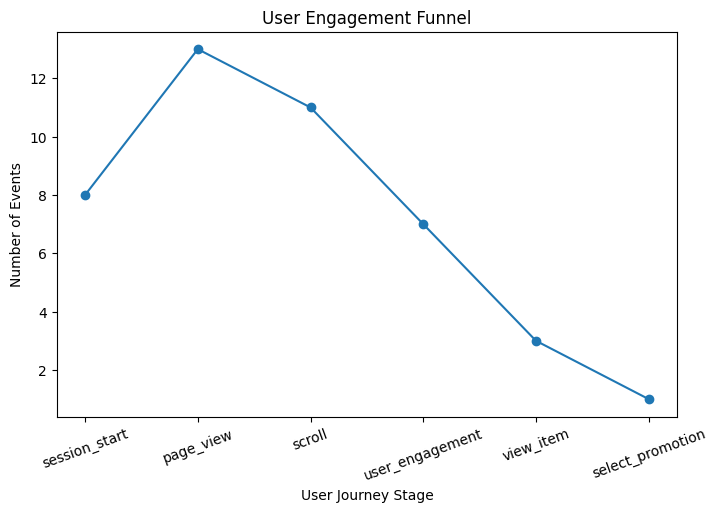

In [19]:
funnel_events = ['session_start', 'page_view', 'scroll', 'user_engagement', 'view_item', 'select_promotion']

funnel_counts = [
    (df['event_name'] == event).sum()
    for event in funnel_events
]

plt.figure(figsize=(8,5))

plt.plot(funnel_events, funnel_counts, marker='o')

plt.title("User Engagement Funnel")
plt.xlabel("User Journey Stage")
plt.ylabel("Number of Events")

plt.xticks(rotation=20)

plt.show()

In [ ]:
# User Journey and Drop-Off Analysis

The user engagement funnel showed a gradual reduction in user interactions as users moved deeper into the website journey.

## Funnel Flow
session_start → page_view → scroll → user_engagement → view_item → select_promotion

## Key Observations
- Many users started sessions and viewed pages.
- A smaller number of users continued scrolling and engaging with content.
- Product interaction events were lower.
- Promotion selection events were minimal.

## Interpretation
This indicates that while users are visiting the website, only a smaller percentage proceed toward deeper engagement or promotional interaction.

Potential improvements include:
- Better call-to-action placement
- Improved product visibility
- Stronger promotional design
- Enhanced user experience optimization

In [ ]:
# Conclusion

This project analyzed website traffic and user behavior using Google Analytics event data.

## Major Findings
- Page views were the most common user activity.
- Google was the largest traffic source.
- Desktop users formed the majority of visitors.
- Chrome was the most-used browser.
- User engagement decreased as interaction depth increased.

## Business Recommendations
- Improve conversion-focused page design.
- Optimize promotional visibility.
- Enhance mobile user experience.
- Encourage deeper user engagement through interactive content.

The analysis demonstrated how web traffic analytics can help businesses understand visitor behavior and improve user engagement strategies.